In [1]:
import numpy as np
import matplotlib.pyplot as plt

Resource: https://stackoverflow.com/questions/26089893/understanding-numpys-einsum
- multiply A with B in a particular way to create new array of products; and then maybe
- sum this new array along particular axes; and then maybe
- transpose the axes of the new array in a particular order.


Math notation to einsum:
https://rockt.ai/2018/04/30/einsum

In [2]:
# Source - https://stackoverflow.com/a/33641428
# Posted by Alex Riley, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-18, License - CC BY-SA 4.0

A = np.array([0, 1, 2])

B = np.array([[ 0,  1,  2,  3],
              [ 4,  5,  6,  7],
              [ 8,  9, 10, 11]])


#### Example 1

In [8]:
# Example 1:
# Multiply A and B then sum along rows of new arrray
print(f"A[:, np.newaxis].shape = {A[:, np.newaxis].shape}")
print(f"B.shape = {B.shape}\n")
print(f"(A[:, np.newaxis] * B) =\n{(A[:, np.newaxis] * B)}")

result = (A[:, np.newaxis] * B).sum(axis=1)
print(f"\nresult = {result}")


A[:, np.newaxis].shape = (3, 1)
B.shape = (3, 4)

(A[:, np.newaxis] * B) =
[[ 0  0  0  0]
 [ 4  5  6  7]
 [16 18 20 22]]

result = [ 0 22 76]


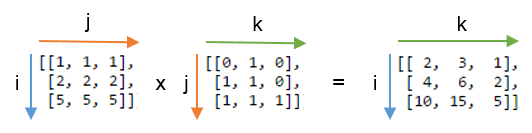

In [11]:
# Einsum version:
# A is labelled i
# B has two axes, labelled i and j respectively

# By repeating label i in both input arrrays, we tell einsum to multiply
# together. i.e multplying array A with each columm of B.
# j doesnt appear as a label in desired output, so we tell einsum to sum along that axis
# via omitting it
result_einsum = np.einsum('i,ij->i', A, B)
print(f"result_einsum = {result_einsum}")


result_einsum = [ 0 22 76]


In [ ]:
# Sum along rows of B
np.einsum('i,ij->j', A, B)

array([20, 23, 26, 29])

#### Bigger example

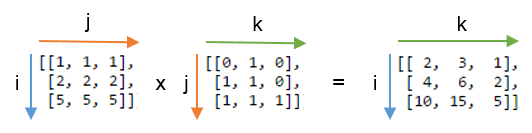

In [15]:
# Source - https://stackoverflow.com/a/33641428
# Posted by Alex Riley, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-18, License - CC BY-SA 4.0

A = np.array([[1, 1, 1],
           [2, 2, 2],
           [5, 5, 5]])

B = np.array([[0, 1, 0],
           [1, 1, 0],
           [1, 1, 1]])


In [18]:
# Computing the dot product of A and B using einsum
np.einsum('ij,jk->ik', A, B)

array([[ 2,  3,  1],
       [ 4,  6,  2],
       [10, 15,  5]])

In [20]:
# Dot product example 2
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

result_einsum = np.einsum('ij,jk->ik', A, B)
print(f"result_einsum =\n{result_einsum}")

result_einsum =
[[19 22]
 [43 50]]


#### Math Notation Example

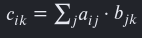

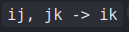

In [21]:
# Create two matrices
# Matrix A: shape (2, 3)
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# Matrix B: shape (3, 2)
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])

# Compute matrix multiplication with einsum
C = np.einsum('ij, jk -> ik', A, B)

print(C)

[[ 58  64]
 [139 154]]


##### Exercises

In [22]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# Matrix B: shape (3, 2)
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])

In [ ]:
# Sum of A along axis
np.einsum('ij->i', A)

array([ 6, 15])

In [26]:
np.einsum('ij->j', A)

array([5, 7, 9])

In [30]:
A = np.arange(10)
B = np.arange(5, 15)

print(f"A = {A}")
print(f"B = {B}")

A = [0 1 2 3 4 5 6 7 8 9]
B = [ 5  6  7  8  9 10 11 12 13 14]


In [31]:
# Sum of A
np.einsum('i->', A)

np.int64(45)

In [33]:
# Element-wise multiplication of A and B
np.einsum('i,i->i', A, B)

array([  0,   6,  14,  24,  36,  50,  66,  84, 104, 126])

##### 2D Matrices Exercises

In [34]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

In [35]:
# Trace of A (sum of diagonal elements)
np.einsum('ii', A)

np.int64(5)

In [36]:
# Element wise of A and transpose of B, A * B.T
np.einsum('ij,ji->ij', A, B)

array([[ 5, 14],
       [18, 32]])

In [37]:
# Multiplying each element of A by D 
# A[:, :, None, None] * D
np.einsum('ij,kl->ijkl', A, B)

array([[[[ 5,  6],
         [ 7,  8]],

        [[10, 12],
         [14, 16]]],


       [[[15, 18],
         [21, 24]],

        [[20, 24],
         [28, 32]]]])